<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum09"

In [4]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import pandas as pd             # Untuk membaca dan mengolah dataset
import numpy as np              # Untuk operasi numerik
import matplotlib.pyplot as plt # Untuk visualisasi grafik
import seaborn as sns           # Untuk visualisasi statistik

from sklearn.model_selection import train_test_split, cross_val_score  # Split data & validasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Evaluasi
from sklearn.preprocessing import StandardScaler  # Normalisasi fitur
from sklearn.naive_bayes import GaussianNB        # Algoritma Naive Bayes

In [5]:
# ==========================================================
# LOADING DATASET
# ==========================================================

file_path = "/data/data.csv"   # Lokasi file yang kamu upload
df = pd.read_csv(path + file_path)   # Membaca dataset ke DataFrame

df.head()  # Menampilkan 5 baris pertama untuk melihat struktur data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
# Melihat informasi lengkap dataset
df.info()   # Menampilkan tipe data, jumlah kolom, non-null, dll

# Menampilkan jumlah baris dan kolom
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

(569, 33)

In [7]:
# ==========================================================
# MISSING VALUE & DROP KOLOM TIDAK RELEVAN
# ==========================================================

# Kolom 'id' tidak berguna untuk prediksi
# Kolom 'Unnamed: 32' berisi NaN semua
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# Mengecek apakah masih ada missing value
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


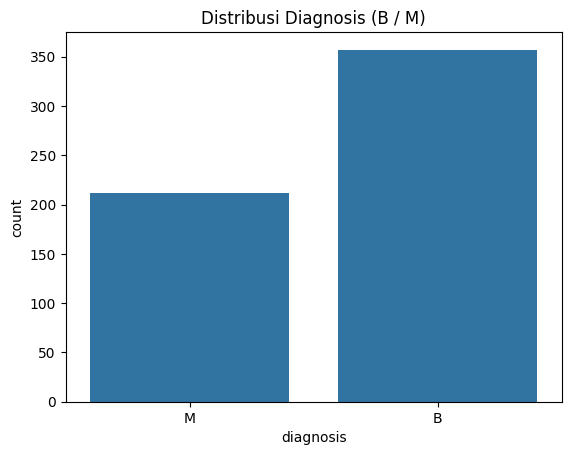

In [8]:
# ==========================================================
# DATA ANALYSIS & ENCODING
# ==========================================================

# Statistik deskriptif fitur numerik
df.describe()

# Melihat distribusi label diagnosis (Benign / Malignant)
df['diagnosis'].value_counts()

# Visualisasi bar jumlah diagnosis
sns.countplot(x='diagnosis', data=df)
plt.title('Distribusi Diagnosis (B / M)')
plt.show()

# Encoding target diagnosis:
# B -> 0 (jinak)
# M -> 1 (ganas)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [9]:
# ==========================================================
# SEPARATING, SPLITTING, SCALING
# ==========================================================

# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['diagnosis'])  # Semua kolom kecuali diagnosis
y = df['diagnosis']                 # Label yang diprediksi

# Membagi dataset: 80% training, 20% testing
# stratify=y digunakan agar proporsi kelas tetap sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Normalisasi fitur menggunakan StandardScaler
scaler = StandardScaler()

# Fit scaler ke data training dan transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform data testing menggunakan scaler training
X_test_scaled = scaler.transform(X_test)

In [12]:
# ==========================================================
# TRAINING MODEL NAIVE BAYES
# ==========================================================

nb_model = GaussianNB()                   # Membuat model Gaussian Naive Bayes
nb_model.fit(X_train_scaled, y_train)     # Melatih model dengan data training

GaussianNB()

In [11]:
# ==========================================================
# EVALUASI MODEL
# ==========================================================

# Prediksi data testing
y_pred = nb_model.predict(X_test_scaled)

# Akurasi data training dan testing
train_acc = nb_model.score(X_train_scaled, y_train)
test_acc = nb_model.score(X_test_scaled, y_test)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

Training Accuracy : 0.945054945054945
Testing Accuracy  : 0.9210526315789473


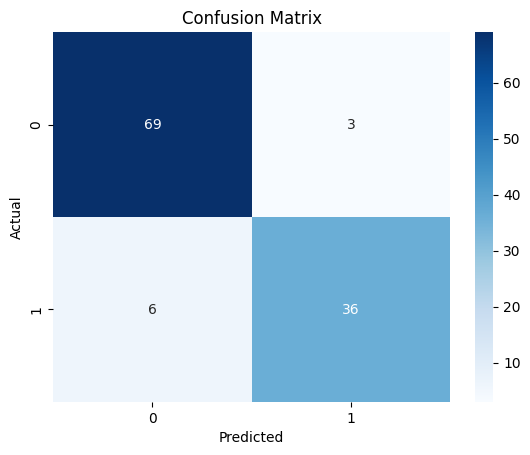

In [13]:
# CONFUSION MATRIX VISUALIZATION

cm = confusion_matrix(y_test, y_pred)  # Membuat confusion matrix

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
# PRINT CLASSIFICATION REPORT

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [15]:
# ==========================================================
# CROSS VALIDATION
# ==========================================================

# Melakukan 5-fold cross validation
cv_scores = cross_val_score(nb_model, X, y, cv=5)

print("Cross Validation Scores :", cv_scores)
print("Mean Accuracy           :", cv_scores.mean())
print("Std Deviation           :", cv_scores.std())

Cross Validation Scores : [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]
Mean Accuracy           : 0.9385188635305075
Std Deviation           : 0.014585994424363306
